## Importing the libraries

In [32]:
import pandas as pd
import numpy as np
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

## Data Loading of three different stocks of Past 6 years from 2020 to 2026

In [3]:
stocks = ["AAPL", "TSLA", "AMZN"]

def load_data(stocks):
  data = yf.download(stocks, start = "2020-01-01", end = "2026-01-01")
  return data[['Close']]

datasets = {stock: load_data(stock) for stock in stocks}

/tmp/ipykernel_16703/561341454.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start = "2020-01-01", end = "2026-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_16703/561341454.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start = "2020-01-01", end = "2026-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_16703/561341454.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start = "2020-01-01", end = "2026-01-01")
[*********************100%***********************]  1 of 1 completed


In [5]:
datasets

{'AAPL': Price            Close
 Ticker            AAPL
 Date                  
 2020-01-02   72.400497
 2020-01-03   71.696648
 2020-01-06   72.267921
 2020-01-07   71.928055
 2020-01-08   73.085106
 ...                ...
 2025-12-24  273.554016
 2025-12-26  273.144409
 2025-12-29  273.504089
 2025-12-30  272.824707
 2025-12-31  271.605835
 
 [1508 rows x 1 columns],
 'TSLA': Price            Close
 Ticker            TSLA
 Date                  
 2020-01-02   28.684000
 2020-01-03   29.534000
 2020-01-06   30.102667
 2020-01-07   31.270666
 2020-01-08   32.809334
 ...                ...
 2025-12-24  485.399994
 2025-12-26  475.190002
 2025-12-29  459.640015
 2025-12-30  454.429993
 2025-12-31  449.720001
 
 [1508 rows x 1 columns],
 'AMZN': Price            Close
 Ticker            AMZN
 Date                  
 2020-01-02   94.900497
 2020-01-03   93.748497
 2020-01-06   95.143997
 2020-01-07   95.343002
 2020-01-08   94.598503
 ...                ...
 2025-12-24  232.380005
 2025-12

## Preprocessing

In [23]:
def create_dataset(data, window=180):
  scaler = MinMaxScaler()
  scaled = scaler.fit_transform(data)
  X , y = [] , []

  for i in range(window, len(scaled)):
    X.append(scaled[i-window:i])
    y.append(scaled[i])

  return np.array(X), np.array(y), scaler

## Building RNN Model

In [25]:
def build_rnn(input_shape):
  model = Sequential([
      SimpleRNN(50, input_shape = input_shape),
      Dense(1)
  ])

  model.compile(optimizer = 'adam', loss = 'mse')
  return model

## Building LSTM Model

In [27]:
def build_lstm(input_shape):
  model = Sequential([
      LSTM(50, input_shape = input_shape),
      Dense(1)
  ])

  model.compile(optimizer = 'adam', loss = 'mse')
  return model

## Training pipeline for both RNN and LSTM for all Stocks

In [29]:
stocks = ["AAPL", "TSLA", "AMZN"]

results = {}

for stock in stocks:
  print(f"\n Training {stock}")

  data = datasets[stock]

  X, y, scaler = create_dataset(data.values)

  split = int( 0.8 * len(X))
  X_train, y_train = X[:split], y[:split]
  X_test, y_test = X[split:], y[split:]

  # RNN Model
  rnn = build_rnn((X_train.shape[1], 1))
  rnn.fit(X_train, y_train, epochs = 10, batch_size = 32, verbose = 1)

  # LSTM Model
  lstm = build_lstm((X_train.shape[1], 1))
  lstm.fit(X_train, y_train, epochs = 10, batch_size = 32, verbose = 1)

  results[stock] = (rnn, lstm, X_test, y_test, scaler)


 Training AAPL


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0077
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 9.7948e-04
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 7.2115e-04
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 6.4830e-04
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 6.2979e-04
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 5.4081e-04
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 5.9800e-04
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 5.3168e-04
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 4.4584e-04
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.7107e-04
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0134
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0011
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 6.3030e-04
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 5.0471e-04
Epoch 5/10
34/34 ━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0584
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0072
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0036
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0019
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0012
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 9.4447e-04
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 9.6011e-04
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 9.2921e-04
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.6571e-04
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.5472e-04
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0140
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0017
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0014
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0013
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0012


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0107
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0020
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0015
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0014
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0011
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0010
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0010
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 8.3341e-04
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.7840e-04
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 7.7474e-04
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0266
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0025
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0015
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0013
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0013
Epoch 6/

## Evaluation of Models

In [31]:
for stock, (rnn, lstm, X_test, y_test, scaler) in results.items():

  rnn_predictions = scaler.inverse_transform(rnn.predict(X_test))
  lstm_predictions = scaler.inverse_transform(lstm.predict(X_test))
  actual = scaler.inverse_transform(y_test)

  rnn_rmse = np.sqrt(mean_squared_error(actual, rnn_predictions))
  lstm_rmse = np.sqrt(mean_squared_error(actual, lstm_predictions))

  print(f"\n {stock}")
  print(f"RNN RMSE: {rnn_rmse}")
  print(f"LSTM RMSE: {lstm_rmse}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step

 AAPL
RNN RMSE: 8.675349060513417
LSTM RMSE: 7.798294878410596
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step

 TSLA
RNN RMSE: 22.622142183436146
LSTM RMSE: 19.201138131778727
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step

 AMZN
RNN RMSE: 8.34720483355669
LSTM RMSE: 7.976007630538413


## Visualisation and comparing both models

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


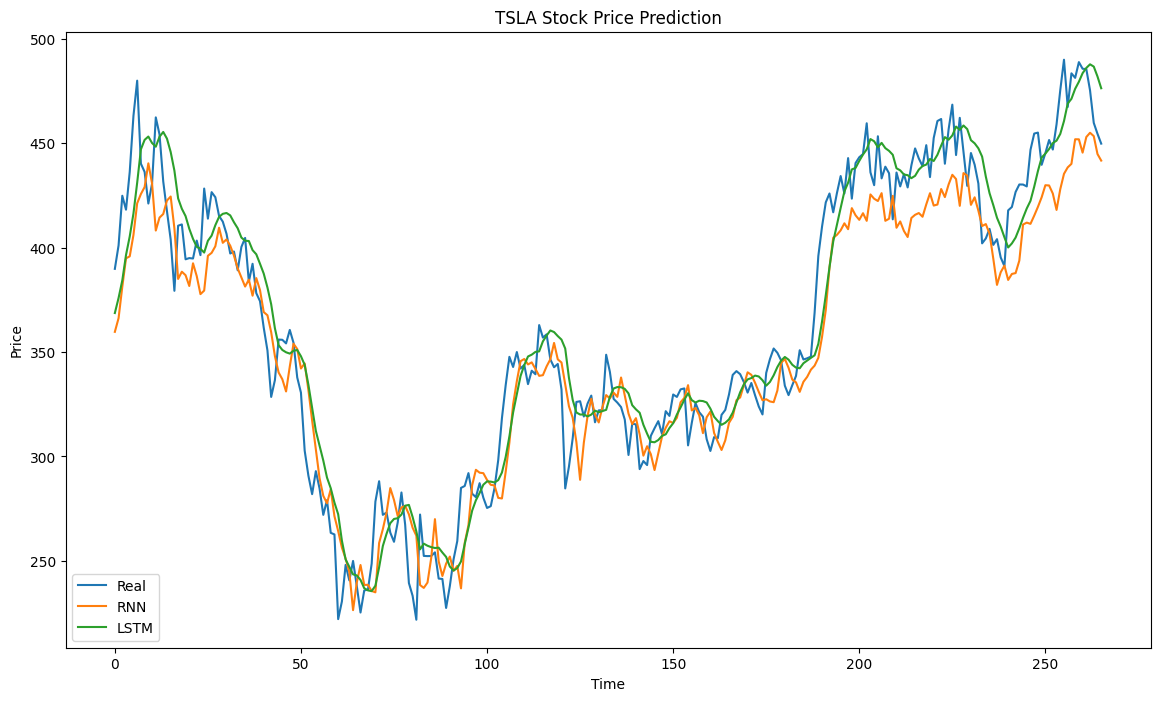

In [39]:
stock = "TSLA"
rnn, lstm, X_test, y_test, scaler = results[stock]

rnn_predictions = scaler.inverse_transform(rnn.predict(X_test))
lstm_predictions = scaler.inverse_transform(lstm.predict(X_test))
actual = scaler.inverse_transform(y_test)

plt.figure(figsize = (14, 8))
plt.plot(actual, label = "Real")
plt.plot(rnn_predictions, label = "RNN")
plt.plot(lstm_predictions, label = "LSTM")
plt.title(f"{stock} Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


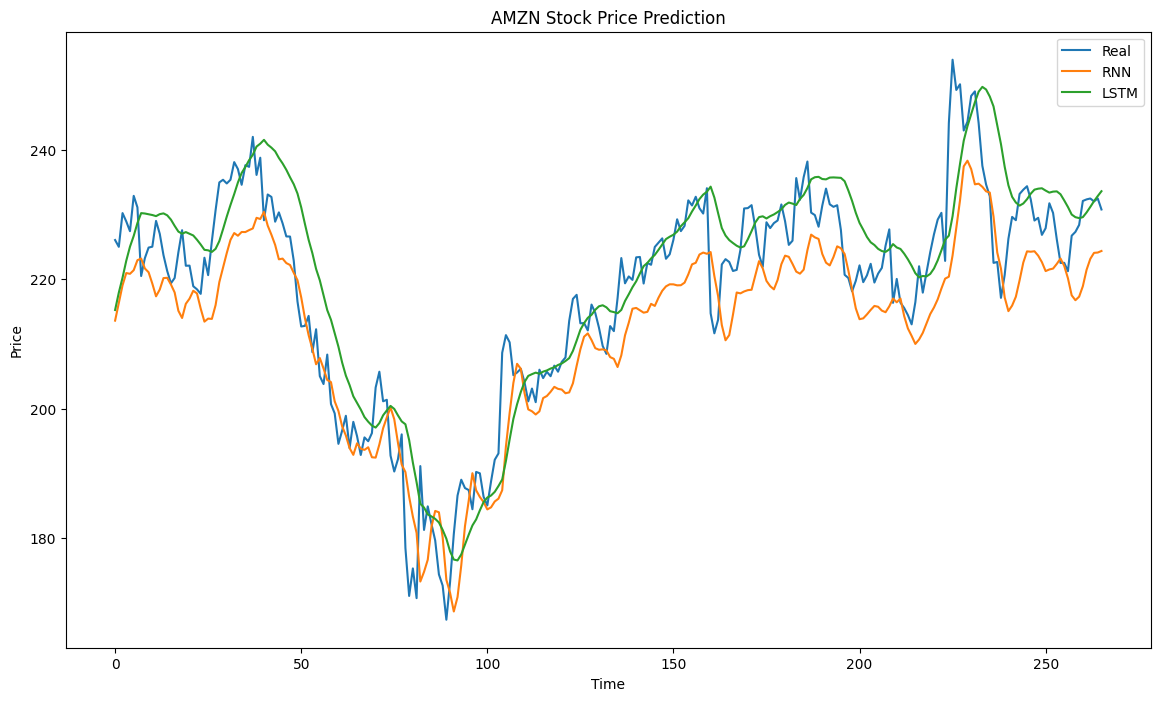

In [38]:
stock = "AMZN"
rnn, lstm, X_test, y_test, scaler = results[stock]

rnn_predictions = scaler.inverse_transform(rnn.predict(X_test))
lstm_predictions = scaler.inverse_transform(lstm.predict(X_test))
actual = scaler.inverse_transform(y_test)

plt.figure(figsize = (14, 8))
plt.plot(actual, label = "Real")
plt.plot(rnn_predictions, label = "RNN")
plt.plot(lstm_predictions, label = "LSTM")
plt.title(f"{stock} Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


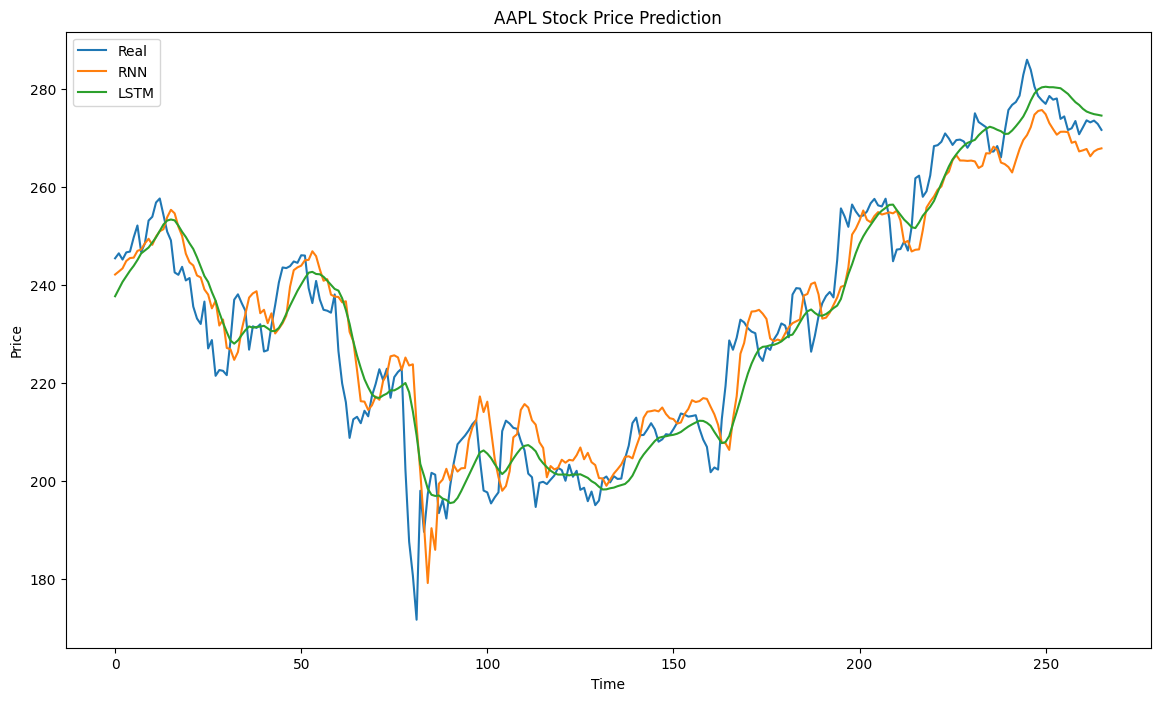

In [37]:
stock = "AAPL"
rnn, lstm, X_test, y_test, scaler = results[stock]

rnn_predictions = scaler.inverse_transform(rnn.predict(X_test))
lstm_predictions = scaler.inverse_transform(lstm.predict(X_test))
actual = scaler.inverse_transform(y_test)

plt.figure(figsize = (14, 8))
plt.plot(actual, label = "Real")
plt.plot(rnn_predictions, label = "RNN")
plt.plot(lstm_predictions, label = "LSTM")
plt.title(f"{stock} Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()